# EduPredict — Exploratory Data Analysis

## Explainable Machine Learning for Early Identification of Students at Academic Risk

### Day 2: Exploratory Data Analysis (EDA)

In this notebook, we explore the structure, distributions, relationships, and potential data quality issues within the dataset before applying machine learning models.

Question

What tools do we need to perform exploratory data analysis and visualization?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

We imported Pandas and NumPy for data manipulation and numerical analysis, and Matplotlib and Seaborn for data visualization.

In [3]:
df = pd.read_csv("../data/raw/data.csv", sep=";")

In [4]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Question

How are the student outcomes distributed across the dataset?

In [5]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [6]:
df["Target"].value_counts(normalize=True) * 100

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

Can we visually compare the number of students in each outcome category?

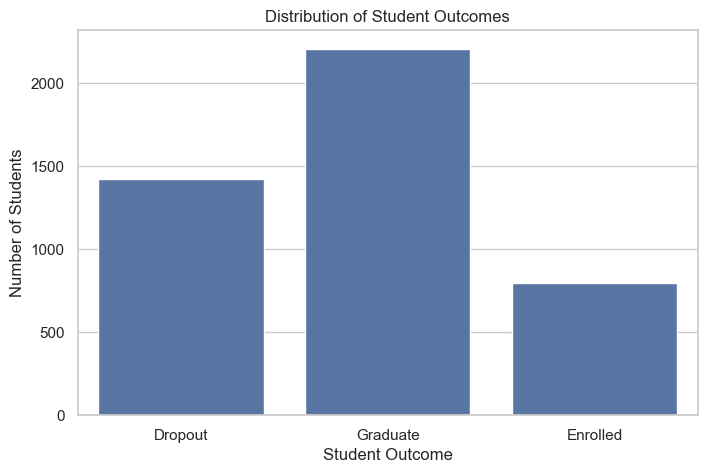

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Target")

plt.title("Distribution of Student Outcomes")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")

plt.show()

Question

What does the distribution of students' age at enrollment look like ؟

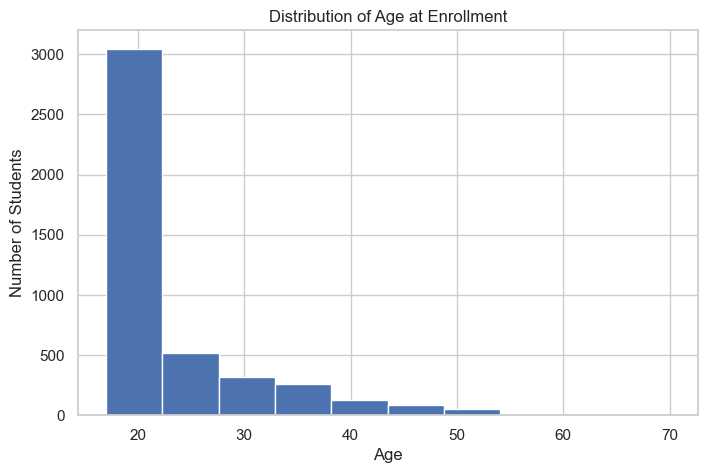

In [12]:
df["Age at enrollment"].hist(figsize=(8, 5))

plt.title("Distribution of Age at Enrollment")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

Question

Are there any unusual or extreme values in students' age at enrollment?

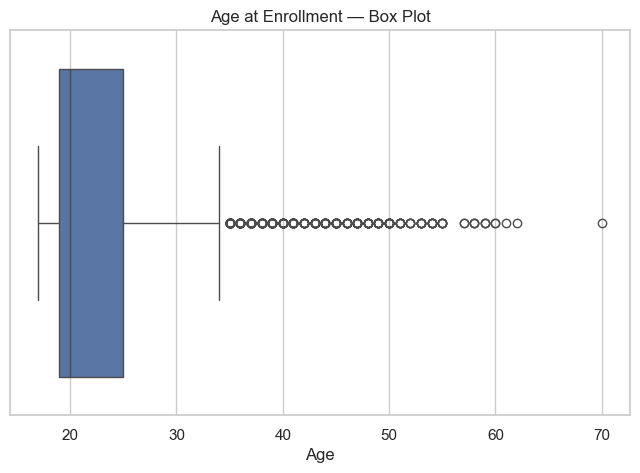

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Age at enrollment")

plt.title("Age at Enrollment — Box Plot")
plt.xlabel("Age")

plt.show()

Question

Does students' age at enrollment differ across the different academic outcomes?

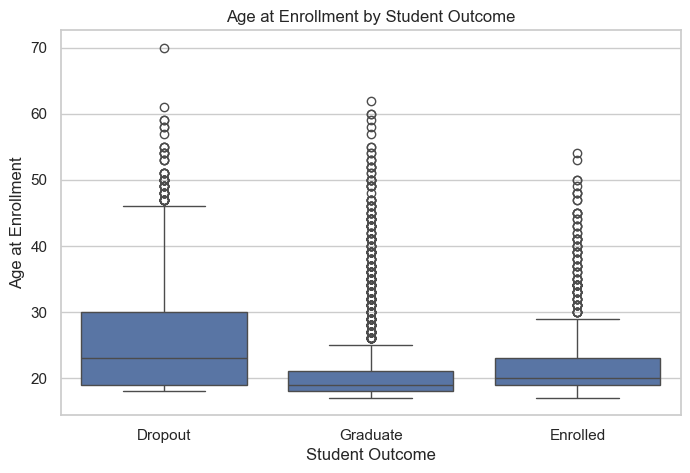

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Target", y="Age at enrollment")

plt.title("Age at Enrollment by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Age at Enrollment")

plt.show()

Question

Does first-semester academic performance differ between students with different outcomes?

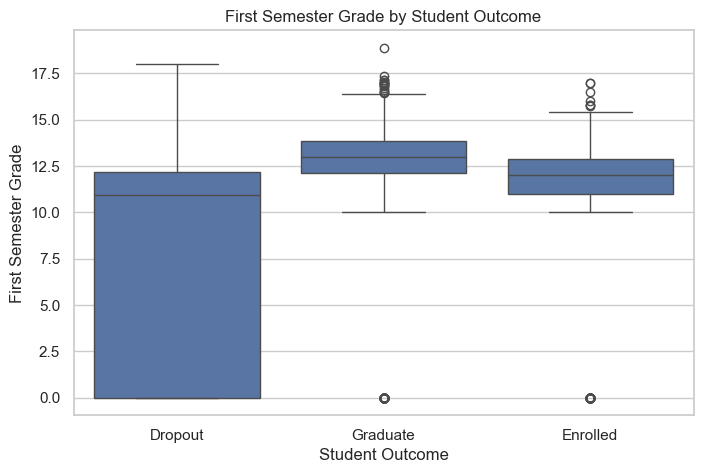

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (grade)"
)

plt.title("First Semester Grade by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("First Semester Grade")

plt.show()

Question

Is there a relationship between students' first-semester and second-semester grades?

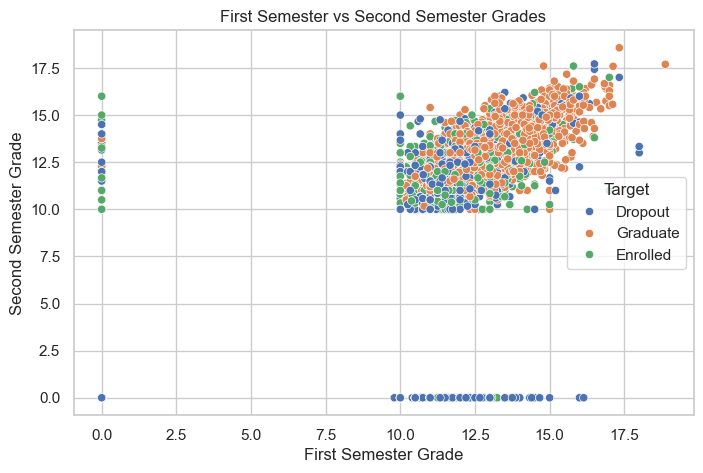

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Curricular units 1st sem (grade)",
    y="Curricular units 2nd sem (grade)",
    hue="Target"
)

plt.title("First Semester vs Second Semester Grades")
plt.xlabel("First Semester Grade")
plt.ylabel("Second Semester Grade")

plt.show()

In [17]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

C:\Users\aasae\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\aasae\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


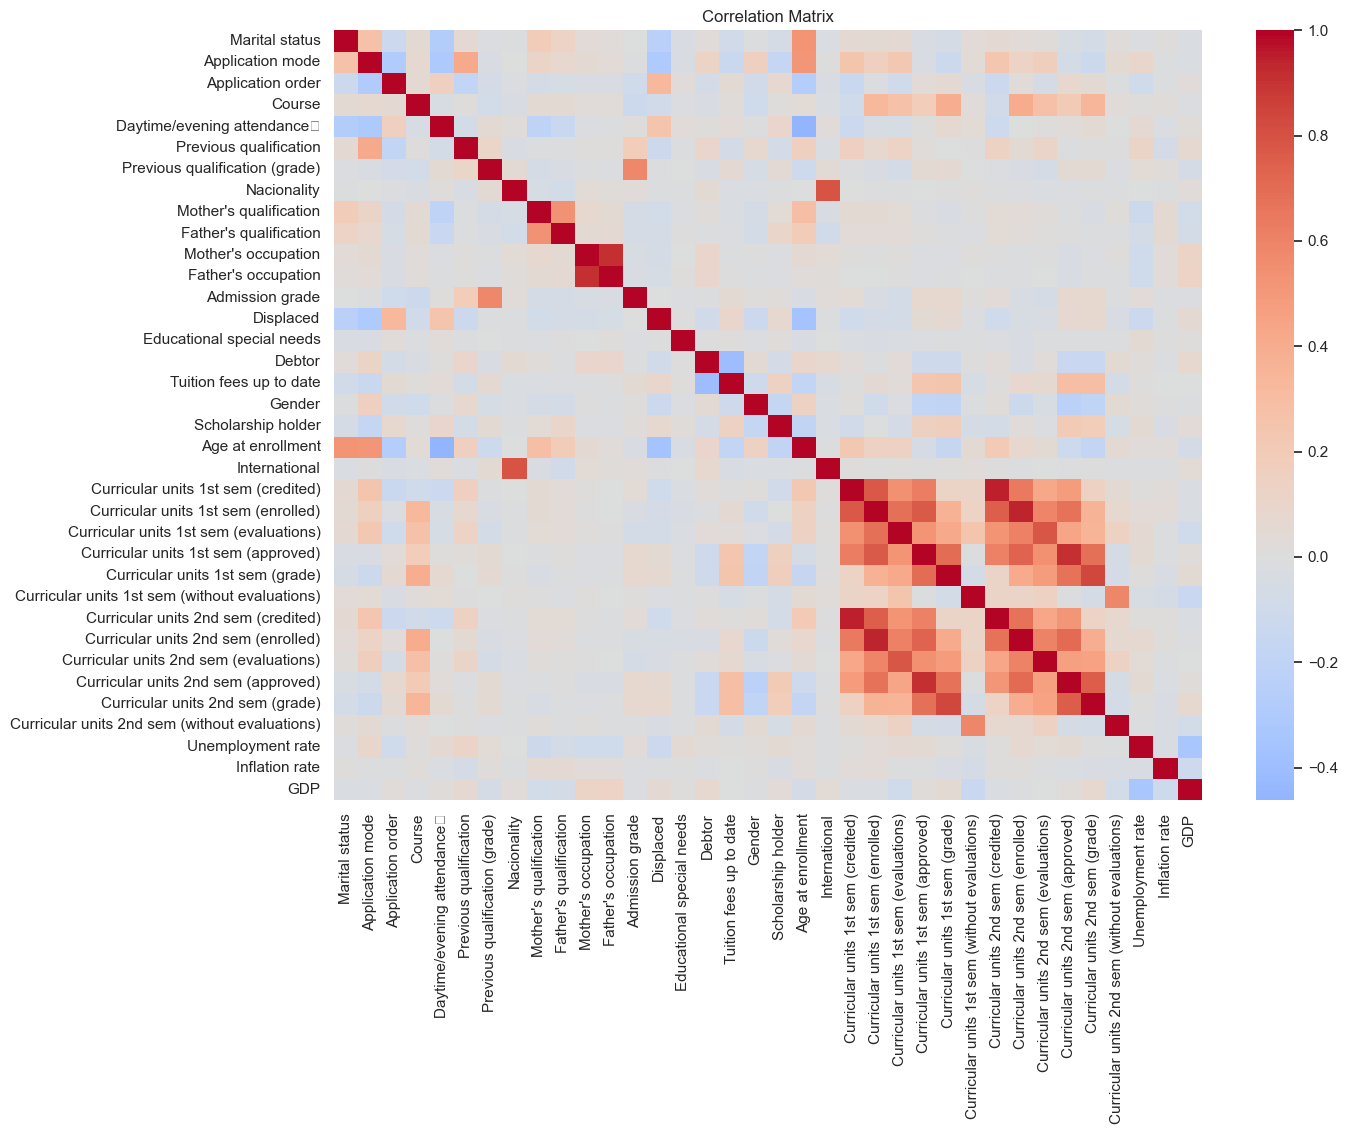

In [18]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows the strength and direction of linear relationships between numerical features. Values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak linear relationship.

In [19]:
df.groupby("Target")["Curricular units 1st sem (grade)"].mean()

Target
Dropout      7.256656
Enrolled    11.125257
Graduate    12.643655
Name: Curricular units 1st sem (grade), dtype: float64

In [20]:
df.groupby("Target")[
    [
        "Age at enrollment",
        "Curricular units 1st sem (grade)",
        "Curricular units 2nd sem (grade)"
    ]
].mean()

,Age at enrollment,Curricular units 1st sem (grade),Curricular units 2nd sem (grade)
Target,,,
Dropout,26.068966,7.256656,5.899339
Enrolled,22.369018,11.125257,11.117364
Graduate,21.783612,12.643655,12.697276
